In [1]:
### Installing Required packages 
import sys
!{sys.executable} -m pip install statsmodels
!{sys.executable} -m pip install pmdarima
!{sys.executable} -m pip install prophet
!{sys.executable} -m pip install plotly

In [2]:
## Loading required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from math import sqrt
from pmdarima import auto_arima
import statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import plotly

In [3]:
# Loading data 
df = pd.read_csv('C:/Users/UserIBM/Documents/Enischyo Intership/exchange rate USD PKR dataset.csv') 

In [4]:
df.head()

,Dataset Name,Observation Date,Series Key,Series Display Name,Observation Value,Unit,Observation Status,Sequence No.,Series name
0,Bank Floating Month End Exchange Rates (USD p...,30-Jun-26,TS_GP_ER_FMEERUSD_M.E00500,50 App (+) / Dep (-) Month End Exchange rate o...,-0.093547,Percent,Normal,500,App (+) / Dep (-) Month End Exchange rate of U...
1,Bank Floating Month End Exchange Rates (USD p...,31-May-26,TS_GP_ER_FMEERUSD_M.E00500,50 App (+) / Dep (-) Month End Exchange rate o...,-0.104970,Percent,Normal,500,App (+) / Dep (-) Month End Exchange rate of U...
2,Bank Floating Month End Exchange Rates (USD p...,30-Apr-26,TS_GP_ER_FMEERUSD_M.E00500,50 App (+) / Dep (-) Month End Exchange rate o...,-0.138828,Percent,Normal,500,App (+) / Dep (-) Month End Exchange rate of U...
3,Bank Floating Month End Exchange Rates (USD p...,31-Mar-26,TS_GP_ER_FMEERUSD_M.E00500,50 App (+) / Dep (-) Month End Exchange rate o...,-0.104226,Percent,Normal,500,App (+) / Dep (-) Month End Exchange rate of U...
4,Bank Floating Month End Exchange Rates (USD p...,28-Feb-26,TS_GP_ER_FMEERUSD_M.E00500,50 App (+) / Dep (-) Month End Exchange rate o...,-0.102672,Percent,Normal,500,App (+) / Dep (-) Month End Exchange rate of U...


In [5]:
# Convert date column
df["Observation Date"] = pd.to_datetime(df["Observation Date"], format="%d-%b-%y")

# Sort by date
df = df.sort_values("Observation Date")

# Set date as index
df.set_index("Observation Date", inplace=True)

# Keep only the exchange rate column
df = df[["Observation Value"]]

# Rename column
df.columns = ["Exchange_Rate"]

# Display first rows
print(df.head())

                  Exchange_Rate
Observation Date               
2001-08-31            -0.131401
2001-09-30            -0.004018
2001-10-31            -3.991712
2001-11-30            -0.996058
2001-12-31            -1.301333


In [6]:
print("Shape:", df.shape)

Shape: (299, 1)


In [7]:
print("First Observation:", df.index.min())
print("Last Observation :", df.index.max())

First Observation: 2001-08-31 00:00:00
Last Observation : 2026-06-30 00:00:00


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 299 entries, 2001-08-31 to 2026-06-30
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Exchange_Rate  299 non-null    float64
dtypes: float64(1)
memory usage: 4.7 KB
None


In [9]:
print(df.describe())

       Exchange_Rate
count     299.000000
mean        0.504626
std         2.327285
min        -8.736589
25%        -0.130424
50%         0.077855
75%         0.584522
max        18.384278


In [10]:
## Checking for missing values 
print(df.isnull().sum())

Exchange_Rate    0
dtype: int64


In [11]:
### checking frequency (daily yearly or monthly data)
print(pd.infer_freq(df.index))

ME


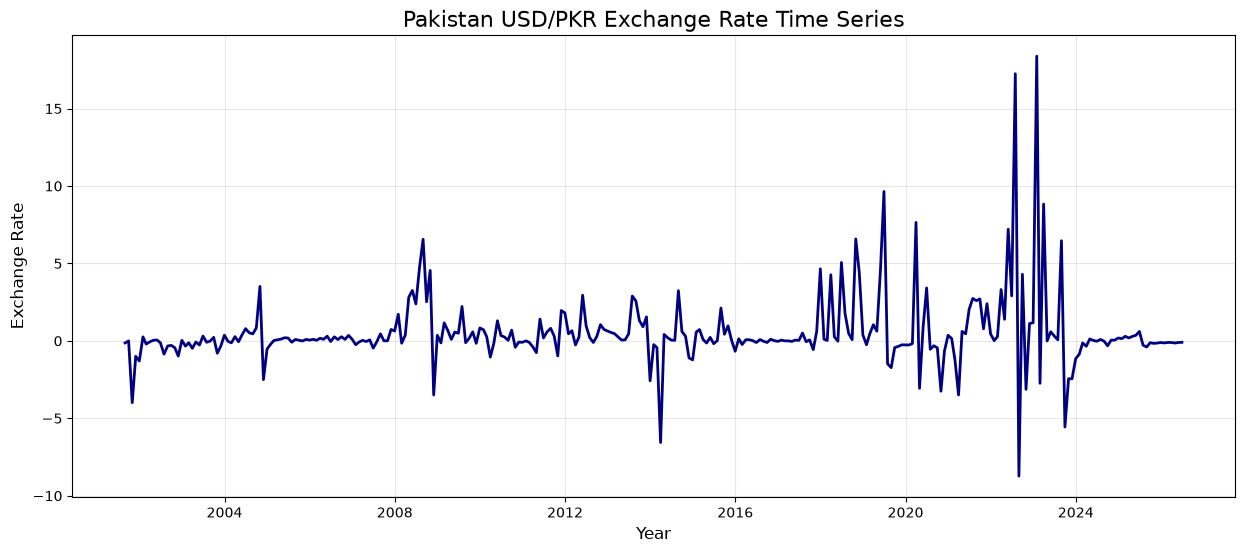

In [12]:
### visualizing time series data
plt.figure(figsize=(15,6))

plt.plot(df.index,
         df["Exchange_Rate"],
         color="navy",
         linewidth=2)

plt.title("Pakistan USD/PKR Exchange Rate Time Series", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Exchange Rate", fontsize=12)

plt.grid(alpha=0.3)

plt.show()

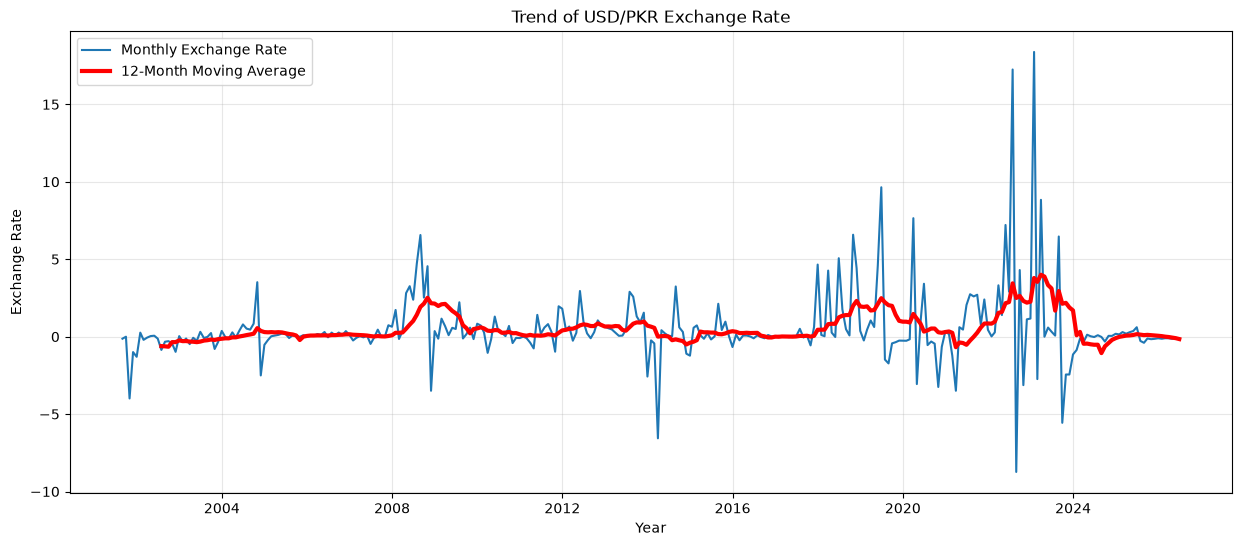

In [13]:
### Moving Average 
df["Moving_Average"] = df["Exchange_Rate"].rolling(12).mean()

plt.figure(figsize=(15,6))

plt.plot(df.index,
         df["Exchange_Rate"],
         label="Monthly Exchange Rate")

plt.plot(df.index,
         df["Moving_Average"],
         color="red",
         linewidth=3,
         label="12-Month Moving Average")

plt.title("Trend of USD/PKR Exchange Rate")
plt.xlabel("Year")
plt.ylabel("Exchange Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

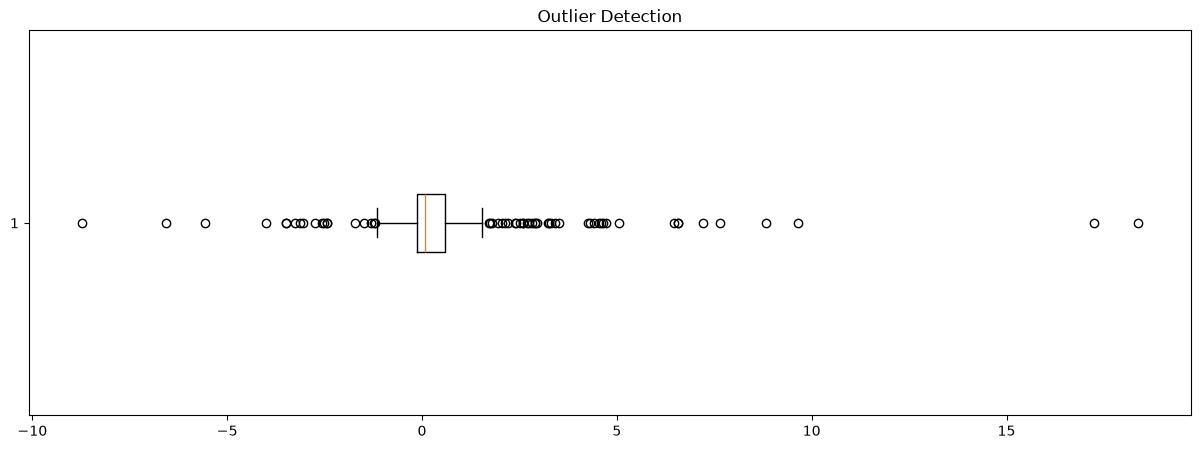

In [15]:
### Detecting Outliers 
plt.figure(figsize=(15,5))
plt.boxplot(df["Exchange_Rate"], orientation="horizontal")
plt.title("Outlier Detection")
plt.show()

In [16]:
### Stationary Testing 

In [17]:
### Define a Function for the ADF Test
def adf_test(series):
    result = adfuller(series.dropna())

    print("Augmented Dickey-Fuller Test")
    print("-"*40)

    print(f"ADF Statistic : {result[0]:.6f}")
    print(f"p-value       : {result[1]:.6f}")
    print(f"Lags Used     : {result[2]}")
    print(f"Observations  : {result[3]}")
    print()

    print("Critical Values")
    for key, value in result[4].items():
        print(f"{key}: {value:.6f}")

    print()

    if result[1] < 0.05:
        print("Result: The series is stationary.")
    else:
        print("Result: The series is non-stationary.")

In [18]:
## Run the ADF Test
adf_test(df["Exchange_Rate"])

Augmented Dickey-Fuller Test
----------------------------------------
ADF Statistic : -4.670563
p-value       : 0.000096
Lags Used     : 6
Observations  : 292

Critical Values
1%: -3.452945
5%: -2.871490
10%: -2.572071

Result: The series is stationary.


In [19]:
### The series are already stationary.Therefore, no need to difference or rerun the ADF test.

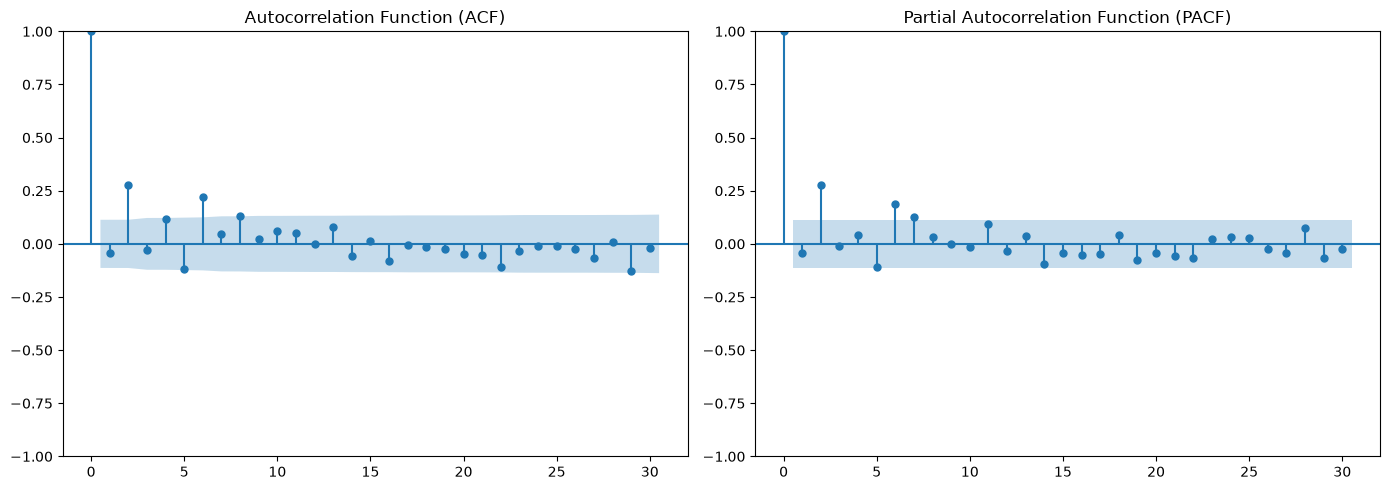

In [20]:
### ACF AND PACF plots 
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df["Exchange_Rate"], ax=ax[0], lags=30)
ax[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(df["Exchange_Rate"], ax=ax[1], lags=30, method="ywm")
ax[1].set_title("Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

In [21]:
### Time Series Decomposition (separates time series into four components: Observed, Trend, Seasonality, Residual)

In [22]:
### Performing Seasonal Decomposition
decomposition = seasonal_decompose(
    df["Exchange_Rate"],
    model="additive",
    period=12
)

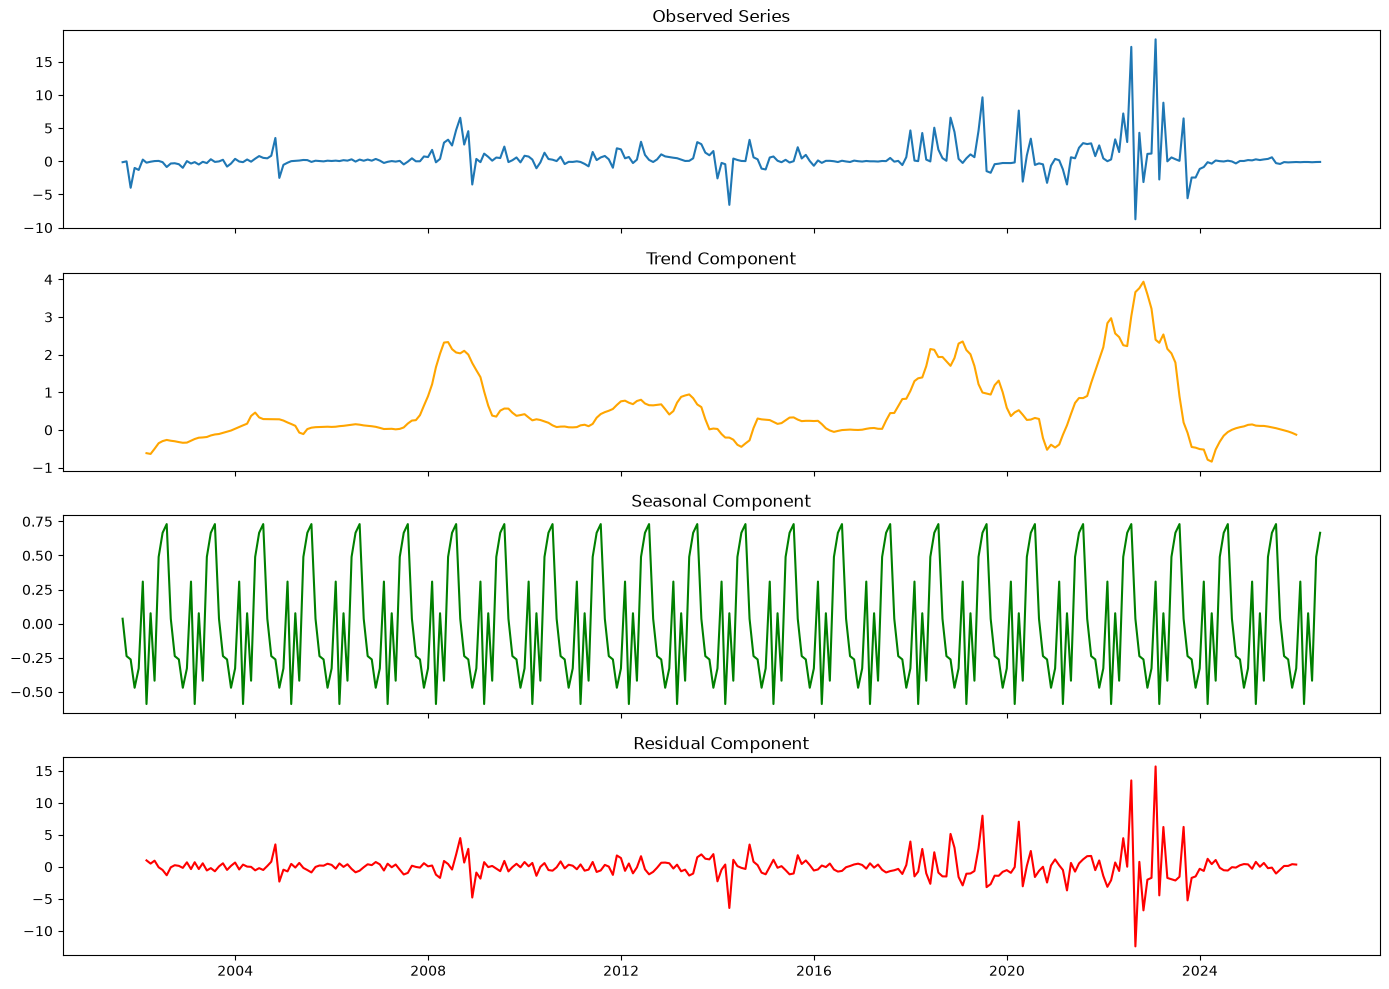

In [24]:
### Ploting All Components indvidually
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(decomposition.observed)
axes[0].set_title("Observed Series")
axes[1].plot(decomposition.trend, color="orange")
axes[1].set_title("Trend Component")
axes[2].plot(decomposition.seasonal, color="green")
axes[2].set_title("Seasonal Component")
axes[3].plot(decomposition.resid, color="red")
axes[3].set_title("Residual Component")
plt.tight_layout()
plt.show()

In [29]:
# Split data into train and test sets
train_size = int(len(df) * 0.80)
train = df.iloc[:train_size]
test = df.iloc[train_size:]
print("Training observations:", len(train))
print("Testing observations :", len(test))

Training observations: 239
Testing observations : 60


In [26]:
### Model Building 

In [32]:
# Month-End frequency
df.index = pd.to_datetime(df.index)
df = df.asfreq("ME")      

In [33]:
### ARIMA Model 
auto_model = auto_arima(
    train["Exchange_Rate"],
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    seasonal=False,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=927.175, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=914.118, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=915.497, Time=0.07 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=915.193, Time=0.21 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=908.155, Time=0.10 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=908.445, Time=0.19 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=908.115, Time=0.18 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=917.177, Time=0.09 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=907.027, Time=0.25 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=908.688, Time=0.49 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=908.661, Time=0.43 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=908.974, Time=0.29 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=911.081, Time=0.13 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.86 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=906.527, 

In [34]:
### Fit the best ARIMA model 
from statsmodels.tsa.arima.model import ARIMA
arima_model = ARIMA(
    train["Exchange_Rate"],
    order=auto_model.order
)
arima_fit = arima_model.fit()
print(arima_fit.summary())

C:\Users\UserIBM\anaconda3\envs\forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\UserIBM\anaconda3\envs\forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\UserIBM\anaconda3\envs\forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:          Exchange_Rate   No. Observations:                  239
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -447.263
Date:                Sun, 19 Jul 2026   AIC                            906.527
Time:                        17:20:10   BIC                            927.386
Sample:                    08-31-2001   HQIC                           914.932
                         - 06-30-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3692      0.245      1.505      0.132      -0.111       0.850
ar.L1         -0.0095      0.149     -0.064      0.949      -0.302       0.283
ar.L2          0.7585      0.111      6.803      0.0

In [35]:
### Forcast using ARIMA
arima_forecast = arima_fit.get_forecast(steps=len(test))
arima_pred = arima_forecast.predicted_mean
arima_ci = arima_forecast.conf_int()

In [36]:
### Evaluate ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from math import sqrt

rmse_arima = sqrt(
    mean_squared_error(
        test["Exchange_Rate"],
        arima_pred
    )
)
mape_arima = mean_absolute_percentage_error(
    test["Exchange_Rate"],
    arima_pred
)
print("ARIMA RMSE :", rmse_arima)
print("ARIMA MAPE :", mape_arima)

ARIMA RMSE : 4.0488967508979465
ARIMA MAPE : 3.962516482511992


In [37]:
### Train the SARIMA Model
sarima_model = SARIMAX(
    train["Exchange_Rate"],
    order=auto_model.order,
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit()
print(sarima_fit.summary())

C:\Users\UserIBM\anaconda3\envs\forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\UserIBM\anaconda3\envs\forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                        Exchange_Rate   No. Observations:                  239
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 12)   Log Likelihood                -413.310
Date:                              Sun, 19 Jul 2026   AIC                            840.621
Time:                                      17:24:02   BIC                            864.117
Sample:                                  08-31-2001   HQIC                           850.117
                                       - 06-30-2021                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2144      0.317      0.676      0.499      -0.407       0.836
ar.L2          0.56

In [38]:
### Forecast with SARIMA
sarima_forecast = sarima_fit.get_forecast(
    steps=len(test)
)
sarima_pred = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

In [39]:
## Evaluate SARIMA model 
rmse_sarima = sqrt(
    mean_squared_error(
        test["Exchange_Rate"],
        sarima_pred
    )
)
mape_sarima = mean_absolute_percentage_error(
    test["Exchange_Rate"],
    sarima_pred
)
print("SARIMA RMSE :", rmse_sarima)
print("SARIMA MAPE :", mape_sarima)

SARIMA RMSE : 4.073305970697278
SARIMA MAPE : 4.825495816177617


In [40]:
### Prepare Data for Prophet
prophet_train = train.reset_index()
prophet_train = prophet_train.rename(
    columns={
        "Observation Date": "ds",
        "Exchange_Rate": "y"
    }
)

In [41]:
### Train Prophet
from prophet import Prophet
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
prophet_model.fit(prophet_train)

17:27:16 - cmdstanpy - INFO - Chain [1] start processing
17:27:17 - cmdstanpy - INFO - Chain [1] done processing


In [42]:
#### Forecast Prophet
future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq="ME"
)
forecast = prophet_model.predict(future)
prophet_pred = forecast["yhat"].tail(len(test)).values
prophet_ci = forecast.tail(len(test))[["yhat_lower", "yhat_upper"]]

In [43]:
### Evaluate Prophet
rmse_prophet = sqrt(
    mean_squared_error(
        test["Exchange_Rate"],
        prophet_pred
    )
)
mape_prophet = mean_absolute_percentage_error(
    test["Exchange_Rate"],
    prophet_pred
)
print("Prophet RMSE :", rmse_prophet)
print("Prophet MAPE :", mape_prophet)

Prophet RMSE : 4.029951649208825
Prophet MAPE : 8.634450614082368


In [44]:
### Compare models 
results = pd.DataFrame({
    "Model": [
        "ARIMA",
        "SARIMA",
        "Prophet"
    ],
    "RMSE": [
        rmse_arima,
        rmse_sarima,
        rmse_prophet
    ],
    "MAPE": [
        mape_arima,
        mape_sarima,
        mape_prophet
    ]
})
results

,Model,RMSE,MAPE
0,ARIMA,4.048897,3.962516
1,SARIMA,4.073306,4.825496
2,Prophet,4.029952,8.634451


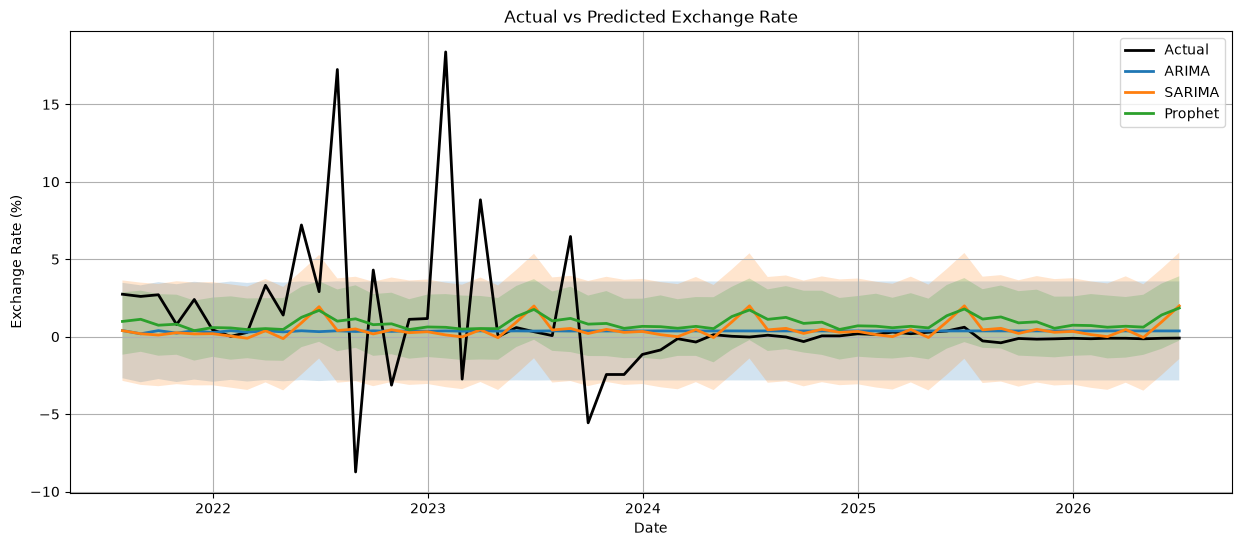

In [45]:
### Plot Actual vs Predicted (All Models) with Confidence Intervals
plt.figure(figsize=(15,6))
# Actual
plt.plot(
    test.index,
    test["Exchange_Rate"],
    color="black",
    linewidth=2,
    label="Actual"
)
# ARIMA
plt.plot(
    test.index,
    arima_pred,
    label="ARIMA",
    linewidth=2
)
plt.fill_between(
    test.index,
    arima_ci.iloc[:,0],
    arima_ci.iloc[:,1],
    alpha=0.20
)
# SARIMA
plt.plot(
    test.index,
    sarima_pred,
    label="SARIMA",
    linewidth=2
)
plt.fill_between(
    test.index,
    sarima_ci.iloc[:,0],
    sarima_ci.iloc[:,1],
    alpha=0.20
)
# Prophet
plt.plot(
    test.index,
    prophet_pred,
    label="Prophet",
    linewidth=2
)
plt.fill_between(
    test.index,
    prophet_ci["yhat_lower"],
    prophet_ci["yhat_upper"],
    alpha=0.20
)
plt.title("Actual vs Predicted Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
#### Forecast the Next 12 Months Using ARIMA 

In [47]:
### Retrain ARIMA on the Complete Dataset
from statsmodels.tsa.arima.model import ARIMA
# Fit ARIMA on the complete dataset
final_model = ARIMA(
    df["Exchange_Rate"],
    order=auto_model.order
)
final_fit = final_model.fit()

In [48]:
# Forecast the next 12 months
future_forecast = final_fit.get_forecast(steps=12)
forecast_mean = future_forecast.predicted_mean
forecast_ci = future_forecast.conf_int(alpha=0.05)

In [49]:
# Create future monthly dates
future_dates = pd.date_range(
    start=df.index[-1] + pd.offsets.MonthEnd(1),
    periods=12,
    freq="ME"
)

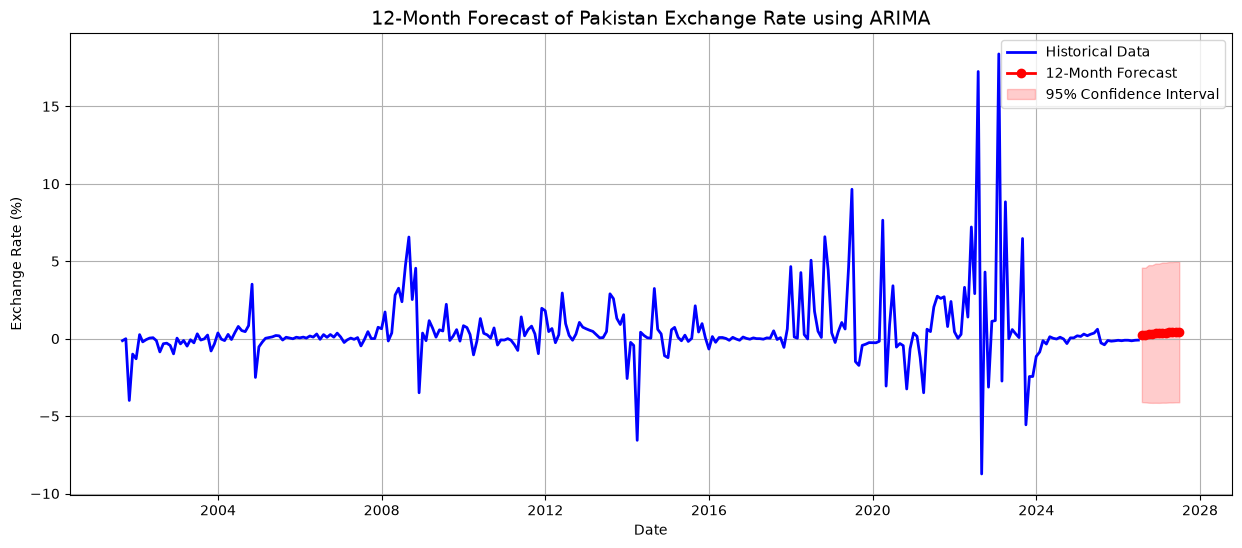

In [50]:
### Plot Forecast with Upper and Lower Bounds
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
# Historical data
plt.plot(
    df.index,
    df["Exchange_Rate"],
    color="blue",
    linewidth=2,
    label="Historical Data"
)
# Forecast
plt.plot(
    future_dates,
    forecast_mean,
    color="red",
    linewidth=2,
    marker="o",
    label="12-Month Forecast"
)
# Confidence intervals
plt.fill_between(
    future_dates,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color="red",
    alpha=0.20,
    label="95% Confidence Interval"
)
plt.title("12-Month Forecast of Pakistan Exchange Rate using ARIMA", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Exchange Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

In [51]:
### Display Forecast Values
forecast_table = pd.DataFrame({
    "Forecast": forecast_mean.values,
    "Lower Bound": forecast_ci.iloc[:, 0].values,
    "Upper Bound": forecast_ci.iloc[:, 1].values
}, index=future_dates)
forecast_table.index.name = "Forecast Date"
forecast_table

,Forecast,Lower Bound,Upper Bound
Forecast Date,,,
2026-07-31,0.242688,-4.099469,4.584845
2026-08-31,0.231807,-4.112779,4.576393
2026-09-30,0.306332,-4.138095,4.750759
2026-10-31,0.299683,-4.145648,4.745015
2026-11-30,0.353306,-4.142819,4.849430
2026-12-31,0.349373,-4.147074,4.845820
2027-01-31,0.387969,-4.134559,4.910497
2027-02-28,0.385753,-4.136881,4.908388
2027-03-31,0.413544,-4.122549,4.949637
